# 1. Pattern Generation

This notebook will show you how to simulate XRD patterns.

In [3]:
# @title Environment Setup
!pip install pymatgen numpy matplotlib -q
# Installation should take > 1 minute to complete
# You may see a dependency conflict warning about 'requests'
# This is harmless and can be ignored
print("Packages installed")

Packages installed


In [4]:
# @title Load Tutorial Data
import os

REPO = "MRS_CH08_Tutorial"
REPO_URL = "https://github.com/Szymanski-Group/MRS_CH08_Tutorial.git"

if os.path.basename(os.getcwd()) == REPO:
    print("Data already present")
elif os.path.exists(REPO):
    os.chdir(REPO)
    print("Data already present")
else:
    !git clone {REPO_URL} -q
    os.chdir(REPO)
    print("Data loaded successfully")


Data loaded successfully


## 1a) Generating Stick Patterns

This code introduces idealized XRD stick patterns using NaCl as a simple example.

In [5]:
from IPython.display import Image, display

def create_stick_pattern(
    struc_path="data/cif/NaCl.cif",
    min_angle=10, max_angle=80,
    wavelen=1.5406 # Cu Ka
):
    # For handling arrays
    import numpy as np

    # For plotting
    import matplotlib.pyplot as plt

    # To load structures and compute XRD patterns
    from pymatgen.core import Structure
    from pymatgen.analysis.diffraction.xrd import XRDCalculator

    # Initialize XRD calculator on NaCl
    pattern = XRDCalculator(wavelength=wavelen).get_pattern(
        Structure.from_file(struc_path),
        two_theta_range=(min_angle, max_angle),
    )

    # Initialize plot
    fig, ax = plt.subplots(figsize=(8, 4))

    # Plot discrete peaks as vertical lines
    ax.vlines(pattern.x, 0, pattern.y, color="black", linewidth=6.5)

    # Formatting
    ax.set_xlim(min_angle, max_angle)
    ax.set_ylim(0, max(pattern.y) * 1.05)
    ax.set_xlabel("2θ", fontsize=18, labelpad=12)
    ax.set_ylabel("Intensity", fontsize=18, labelpad=12)
    ax.tick_params(axis="both", labelsize=15)

    # Save plot
    plt.tight_layout()
    plt.savefig("stick_pattern.png", dpi=200)
    print("\nSaved plot: stick_pattern.png")




Saved plot: stick_pattern.png


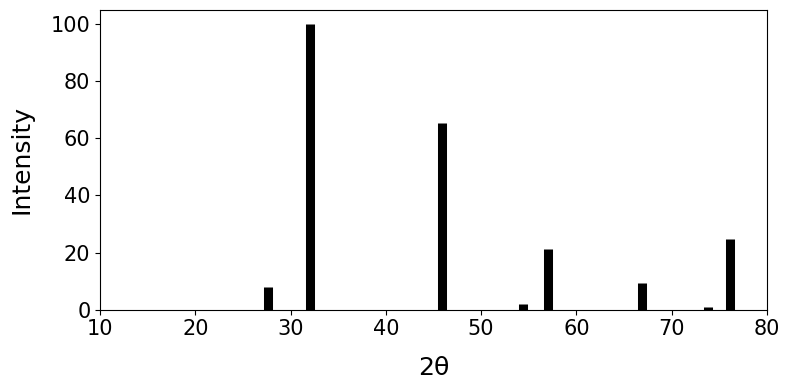

In [6]:
# @title Call the function
create_stick_pattern()


The vertical lines mark Bragg peak positions (2θ) and relative intensities for an ideal crystal of NaCl.


Saved plot: stick_pattern.png


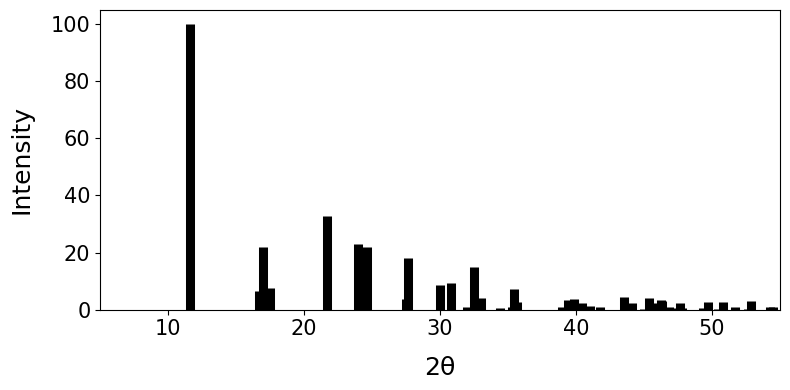

In [10]:
# Try on your own:
  # Vary the wavelength (1.5406 Å is the CuKa value; you can specify others)
  # Load other structures (from data/cif) and plot their XRD stick patterns
  # Plot over different ranges of 2θ

# Example below (for TiO2, Mo Ka radiation, and 2θ from 10 to 60 degrees)
  # create_stick_pattern(struc_path="data/cif/TiO2.cif", wavelen=0.7107,
  #     min_angle=5, max_angle=55)

## 1b) Continuous Patterns

This section broadens idealized "stick" peaks into continuous pseudo-Voigt profiles to mimic realistic measured line shapes.


In [12]:
def create_continuous_pattern(
    struc_path="data/cif/NaCl.cif",
    min_angle=10,
    max_angle=80,
    wavelen="CuKa",
    num_points=4000, # Number of values along the x-axis
    fwhm=0.3,        # Full width at half maximum (FWHM)
    gauss_frac=0.2,  # Fraction of Gaussian (vs. Lorentzian)
    fill_color="blue",
    line_color="darkblue",
    output_file="NaCl_continuous_pattern.png",
):
    # For handling arrays
    import numpy as np

    # For plotting
    import matplotlib.pyplot as plt

    # To load structures and compute XRD patterns
    from pymatgen.core import Structure
    from pymatgen.analysis.diffraction.xrd import XRDCalculator

    def gaussian(x, center, fwhm):
        sigma = fwhm / (2.0 * np.sqrt(2.0 * np.log(2.0)))
        return np.exp(-0.5 * ((x - center) / sigma) ** 2)

    def lorentzian(x, center, fwhm):
        gamma = fwhm / 2.0
        return (gamma**2) / ((x - center) ** 2 + gamma**2)

    # Pseudo-Voigt = a linear combination of
    # Gaussian and Lorentzian profiles
    def pseudo_voigt(x, center, fwhm, eta):
        return (1.0 - eta) * gaussian(x, center, fwhm) \
        + eta * lorentzian(x, center, fwhm)

    pattern = XRDCalculator(wavelength=wavelen).get_pattern(
        Structure.from_file(struc_path),
        two_theta_range=(min_angle, max_angle),
    )

    # Start with discrete "stick" peaks
    peak_pos = np.array(pattern.x)
    peak_intensity = np.array(pattern.y)

    # Define a uniform grid over 2θ, start with y = 0 baseline
    two_theta_grid = np.linspace(min_angle, max_angle, num_points)
    continuous_intensity = np.zeros_like(two_theta_grid)

    # Sum over all continous peak profiles (one for each peak)
    for two_theta, intensity in zip(peak_pos, peak_intensity):
        continuous_intensity += intensity * pseudo_voigt(
            two_theta_grid,
            two_theta,
            fwhm,
            gauss_frac,
        )

    # Normalize intensities (y-values) from 0-1
    continuous_intensity *= peak_intensity.max() / np.clip(
        continuous_intensity.max(),
        1e-12,
        None,
    )

    # Create the plot
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.fill_between(two_theta_grid, 0, continuous_intensity,
                    color=fill_color, alpha=0.25)
    ax.plot(two_theta_grid, continuous_intensity,
            color=line_color, linewidth=2.2)

    ax.set_xlim(min_angle, max_angle)
    ax.set_ylim(0, continuous_intensity.max() * 1.05)
    ax.set_xlabel("2θ", fontsize=18, labelpad=12)
    ax.set_ylabel("Intensity", fontsize=18, labelpad=12)
    ax.tick_params(axis="both", labelsize=15)

    # Save the plot
    plt.tight_layout()
    plt.savefig(output_file, dpi=200)
    print(f"\nLoaded CIF: {struc_path}")
    print(f"Saved plot: {output_file}")



Loaded CIF: data/cif/NaCl.cif
Saved plot: NaCl_continuous_pattern.png


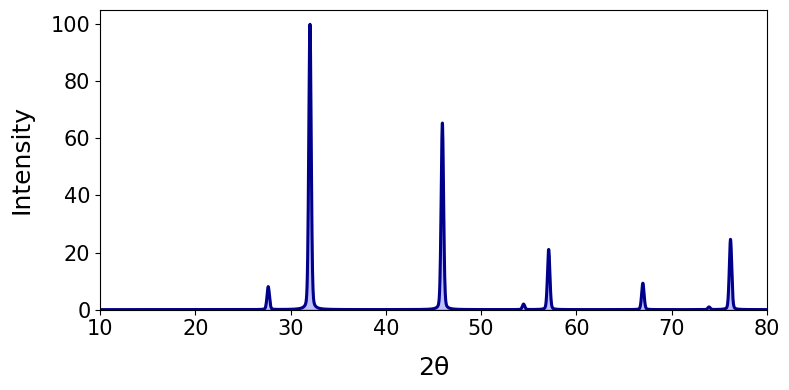

In [13]:
# @title Call the function
create_continuous_pattern()



Loaded CIF: data/cif/NaCl.cif
Saved plot: NaCl_continuous_pattern.png


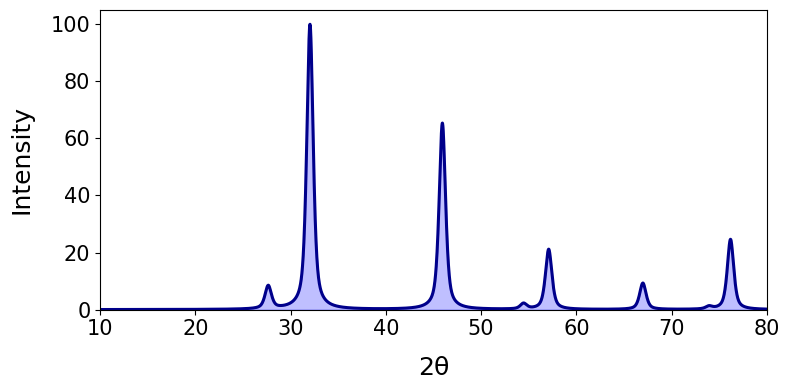

In [14]:
# Try on your own:
  # Increase fwhm to mimic lower instrument resolution
  #   Change gauss_frac (0 = Gaussian, 1 = Lorentzian)
  #   Load another structure from data/cif

# Example below (with broader, more gaussian peaks)
  # create_continuous_pattern(struc_path="data/cif/NaCl.cif",
  #     fwhm=0.8, gauss_frac=0.6)


## 1c) Peak Splitting

This section adds Cu Kα1/Kα2 doublet splitting and highlights the effect at higher angles.


In [15]:
def create_peak_splitting_pattern(
    struc_path="data/cif/NaCl.cif",
    min_angle=10,
    max_angle=80,
    num_points=4000,
    fwhm=0.1,
    gauss_frac=0.2,
    ka1_wavelength=1.5405929, # Wavelength of Cu Ka1
    ka2_wavelength=1.5444260, # Wavelength of Cu Ka2
    ka1_ka2_ratio=2.0,        # Ka1/Ka2 intensity ratio
    zoom_range=(75.0, 77.5),
    zoom_ylim=(0.0, 28.0),
    output_file="NaCl_peak_splitting_pattern.png",
    zoom_output_file="NaCl_zoomed.png",
):
    # For handling arrays
    import numpy as np

    # For plotting
    import matplotlib.pyplot as plt

    # To load structures and compute XRD patterns
    from pymatgen.core import Structure
    from pymatgen.analysis.diffraction.xrd import XRDCalculator

    def gaussian(x, center, fwhm):
        sigma = fwhm / (2.0 * np.sqrt(2.0 * np.log(2.0)))
        return np.exp(-0.5 * ((x - center) / sigma) ** 2)

    def lorentzian(x, center, fwhm):
        gamma = fwhm / 2.0
        return (gamma**2) / ((x - center) ** 2 + gamma**2)

    def pseudo_voigt(x, center, fwhm, eta):
        return (1.0 - eta) * gaussian(x, center, fwhm) \
        + eta * lorentzian(x, center, fwhm)

    structure = Structure.from_file(struc_path)

    # Separately calculate each XRD pattern from Ka1 and Ka2
    pattern_ka1 = XRDCalculator(wavelength=ka1_wavelength).get_pattern(
        structure,
        two_theta_range=(min_angle, max_angle),
    )
    pattern_ka2 = XRDCalculator(wavelength=ka2_wavelength).get_pattern(
        structure,
        two_theta_range=(min_angle, max_angle),
    )

    # Get peak positions and intensities
    peak_pos_ka1 = np.array(pattern_ka1.x)
    peak_intensity_ka1 = np.array(pattern_ka1.y)
    peak_pos_ka2 = np.array(pattern_ka2.x)
    peak_intensity_ka2 = np.array(pattern_ka2.y)

    # Scale the peak intensities
    weight_ka1 = ka1_ka2_ratio / (1.0 + ka1_ka2_ratio)
    weight_ka2 = 1.0 / (1.0 + ka1_ka2_ratio)

    # Define uniform grid over 2θ
    two_theta_grid = np.linspace(min_angle, max_angle, num_points)
    continuous_intensity = np.zeros_like(two_theta_grid)

    # Sum continuous profiles over Ka1 peaks
    for two_theta, intensity in zip(peak_pos_ka1, peak_intensity_ka1):
        continuous_intensity += weight_ka1 * intensity * pseudo_voigt(
            two_theta_grid,
            two_theta,
            fwhm,
            gauss_frac,
        )

    # Sum continuous profiles over Ka2 peaks
    for two_theta, intensity in zip(peak_pos_ka2, peak_intensity_ka2):
        continuous_intensity += weight_ka2 * intensity * pseudo_voigt(
            two_theta_grid,
            two_theta,
            fwhm,
            gauss_frac,
        )

    continuous_intensity *= 100.0 / np.clip(
        continuous_intensity.max(), 1e-12, None)

    # Create full plot
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.fill_between(two_theta_grid, 0, continuous_intensity,
                    color="blue", alpha=0.25)
    ax.plot(two_theta_grid, continuous_intensity,
            color="darkblue", linewidth=1.5)

    ax.set_xlim(min_angle, max_angle)
    ax.set_ylim(0, continuous_intensity.max() * 1.05)
    ax.set_xlabel("2θ", fontsize=18, labelpad=12)
    ax.set_ylabel("Intensity", fontsize=18, labelpad=12)
    ax.tick_params(axis="both", labelsize=15)

    plt.tight_layout()
    plt.savefig(output_file, dpi=200)
    print(f"\nLoaded CIF: {struc_path}")
    print(f"Saved plot: {output_file}")

    # Zoom in on a split peak at higher 2θ
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.fill_between(two_theta_grid, 0, continuous_intensity,
                    color="blue", alpha=0.25)
    ax.plot(two_theta_grid, continuous_intensity,
            color="darkblue", linewidth=1.5)

    ax.set_xlim(*zoom_range)
    ax.set_ylim(*zoom_ylim)

    plt.tight_layout()
    plt.savefig(zoom_output_file, dpi=200)
    print(f"Saved zoomed plot: {zoom_output_file}")



Loaded CIF: data/cif/NaCl.cif
Saved plot: NaCl_peak_splitting_pattern.png
Saved zoomed plot: NaCl_zoomed.png


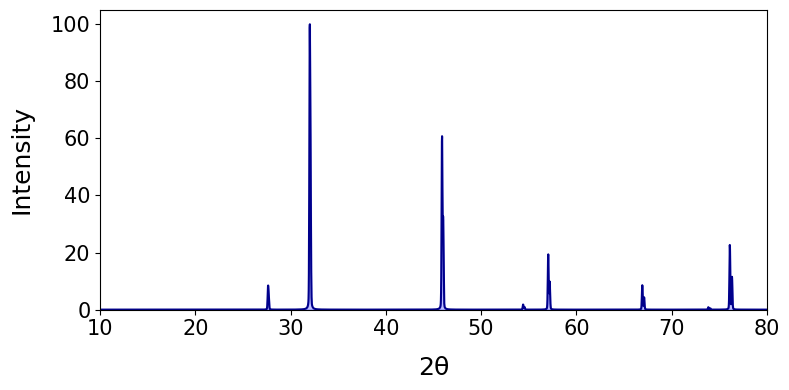

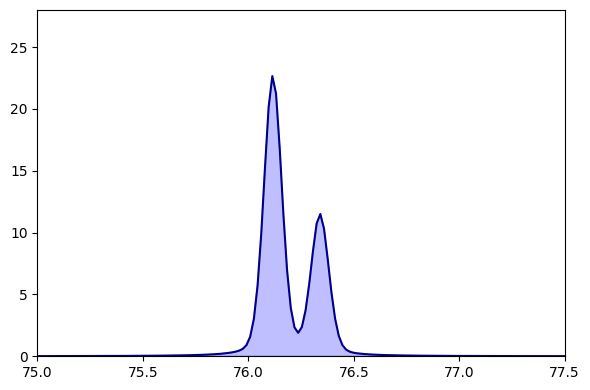

In [16]:
# @title Call the function
create_peak_splitting_pattern()


The zoomed view makes subtle doublet separation more visible at high 2θ.


In [18]:
# Try on your own:
  # Change fwhm to see when splitting becomes easier/harder to resolve

# Example below (with broader peaks, less visible splitting)
  # create_peak_splitting_pattern(max_angle=120, fwhm=0.5)


## 1d) Peak Broadening

This section uses a Scherrer-style model to show how crystallite size affects peak width.


In [19]:
def create_peak_broadening_comparison(
    struc_path="data/cif/TiO2.cif",
    min_angle=10,
    max_angle=80,
    num_points=4000,
    wavelen=1.5406,
    k_factor=0.9,
    # The below sizes are in nanometers (nm)
    # We'll test three domain sizes (30, 10, 5 nm)
    # Which produce increasingly broader peaks
    profiles=(("Large particles", 30.0),
              ("Moderate size", 10.0),
              ("Very small", 5.0)),
    cmap_colors=("#1f4ed8", "#7e22ce", "#dc2626"),
    output_file="TiO2_peak_broadening.png",
):
    # For handling arrays
    import numpy as np

    # For plotting
    import matplotlib.pyplot as plt
    from matplotlib.colors import LinearSegmentedColormap

    # To load structures and compute XRD patterns
    from pymatgen.core import Structure
    from pymatgen.analysis.diffraction.xrd import XRDCalculator

    # Scherrer equation computes FWHM as a function of 2θ
    def scherrer_fwhm_deg(two_theta_deg, crystallite_size_nm):
        theta_rad = np.deg2rad(two_theta_deg / 2.0)
        wavelength_nm = wavelen / 10.0
        beta_rad = k_factor * wavelength_nm / (
            crystallite_size_nm * np.cos(theta_rad))
        return np.rad2deg(beta_rad)

    def gaussian_unit_area(two_theta_grid, centers, fwhm_deg):
        sigma = fwhm_deg / (2.0 * np.sqrt(2.0 * np.log(2.0)))
        dx = two_theta_grid[:, None] - centers[None, :]
        return np.exp(-0.5 * (dx / sigma[None, :]) ** 2) / (
            sigma[None, :] * np.sqrt(2.0 * np.pi)
        )

    def broaden_pattern(two_theta_grid, peak_pos, peak_intensity, size_nm):
        fwhm = scherrer_fwhm_deg(peak_pos, size_nm)
        profile = gaussian_unit_area(two_theta_grid, peak_pos, fwhm)
        intensity = profile @ peak_intensity
        return 100.0 * intensity / np.clip(intensity.max(), 1e-12, None)

    pattern = XRDCalculator(wavelength=wavelen).get_pattern(
        Structure.from_file(struc_path),
        two_theta_range=(min_angle, max_angle),
    )

    peak_pos = np.array(pattern.x)
    peak_intensity = np.array(pattern.y)
    peak_intensity = 100.0 * peak_intensity / np.clip(
        peak_intensity.max(), 1e-12, None)

    two_theta_grid = np.linspace(min_angle, max_angle, num_points)

    profile_cmap = LinearSegmentedColormap.from_list(
        "size_profile_map", list(cmap_colors))
    colors = [profile_cmap(v) for v in np.linspace(0.0, 1.0, len(profiles))]

    fig, axes = plt.subplots(nrows=len(profiles),
                             ncols=1, figsize=(8, 7), sharex=True)
    if len(profiles) == 1:
        axes = [axes]

    for ax, color, (label, size_nm) in zip(axes, colors, profiles):
        continuous_intensity = broaden_pattern(
            two_theta_grid, peak_pos, peak_intensity, size_nm)
        ax.fill_between(two_theta_grid, 0, continuous_intensity,
                        color=color, alpha=0.25)
        ax.plot(two_theta_grid, continuous_intensity,
                color=color, linewidth=2.2)
        ax.set_title(f"{label} ({size_nm} nm)", fontsize=14, pad=4)
        ax.set_xlim(min_angle, max_angle)
        ax.set_ylim(0, 105)
        ax.set_ylabel("Intensity", fontsize=16, labelpad=10)
        ax.tick_params(axis="both", labelsize=13)

    axes[-1].set_xlabel("2θ", fontsize=16, labelpad=10)

    plt.tight_layout()
    plt.savefig(output_file, dpi=200)
    print(f"\nLoaded CIF: {struc_path}")
    print(f"Saved plot: {output_file}")
    print("Smaller crystallite size gives broader peaks (larger Scherrer FWHM).")



Loaded CIF: data/cif/TiO2.cif
Saved plot: TiO2_peak_broadening.png
Smaller crystallite size gives broader peaks (larger Scherrer FWHM).


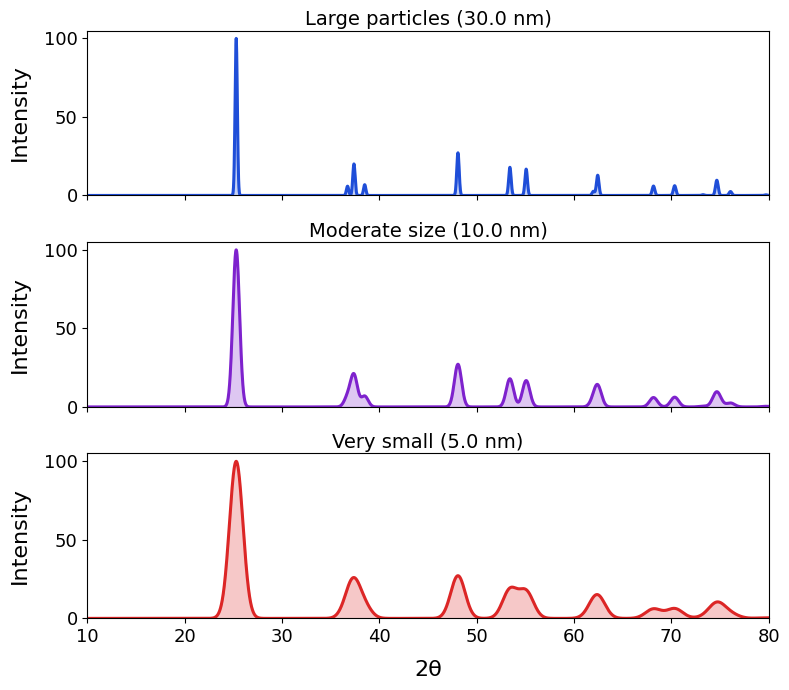

In [20]:
# @title Call the function
create_peak_broadening_comparison()


Smaller crystallite size yields visibly broader peaks which tend to overlap with one another, especially at higher angles.


In [25]:
# Try on your own:
  # Change particle sizes in profiles

# Example below (with very narrow to very broad peaks)
  # create_peak_broadening_comparison(profiles=
  #   (("Large particles", 50.0),
  #   ("Moderate size", 10.0),
  #   ("Very small", 2.0)))

## 1e) Baseline Effects

This section adds background curvature and noise on top of broadened peaks.


In [ ]:
def create_pattern_with_baseline(
    struc_path="data/cif/LiMnO2.cif",
    min_angle=10,
    max_angle=80,
    num_points=4000,
    fwhm=0.30,
    eta=0.5,
    ka1_wavelength=1.5405929,
    ka2_wavelength=1.5444260,
    ka1_ka2_ratio=2.0,
    cheb_coeffs=(1.0, -0.3, 0.15, -0.05, 0.02),
    background_scale=0.24,
    noise_level=0.005,
    baseline_offset=0.01,
    random_seed=42,
    output_file="LiMnO2_xrd_with_background.png",
):
    # For handling arrays
    import numpy as np

    # For plotting
    import matplotlib.pyplot as plt

    # To load structures and compute XRD patterns
    from pymatgen.core import Structure
    from pymatgen.analysis.diffraction.xrd import XRDCalculator

    rng = np.random.default_rng(random_seed)
    cheb_coeffs = np.array(cheb_coeffs, dtype=float)

    def gaussian(x, center, fwhm):
        sigma = fwhm / (2.0 * np.sqrt(2.0 * np.log(2.0)))
        return np.exp(-0.5 * ((x - center) / sigma) ** 2)

    def lorentzian(x, center, fwhm):
        gamma = fwhm / 2.0
        return (gamma**2) / ((x - center) ** 2 + gamma**2)

    def pseudo_voigt(x, center, fwhm, mix):
        return (1.0 - mix) * gaussian(x, center, fwhm) + mix * lorentzian(
            x, center, fwhm
        )

    structure = Structure.from_file(struc_path)

    pattern_ka1 = XRDCalculator(wavelength=ka1_wavelength).get_pattern(
        structure,
        two_theta_range=(min_angle, max_angle),
    )
    pattern_ka2 = XRDCalculator(wavelength=ka2_wavelength).get_pattern(
        structure,
        two_theta_range=(min_angle, max_angle),
    )

    peak_pos_ka1 = np.array(pattern_ka1.x)
    peak_intensity_ka1 = np.array(pattern_ka1.y)
    peak_pos_ka2 = np.array(pattern_ka2.x)
    peak_intensity_ka2 = np.array(pattern_ka2.y)

    two_theta_grid = np.linspace(min_angle, max_angle, num_points)
    peaks = np.zeros_like(two_theta_grid)

    weight_ka1 = ka1_ka2_ratio / (1.0 + ka1_ka2_ratio)
    weight_ka2 = 1.0 / (1.0 + ka1_ka2_ratio)

    for two_theta, intensity in zip(peak_pos_ka1, peak_intensity_ka1):
        peaks += weight_ka1 * intensity * pseudo_voigt(
            two_theta_grid, two_theta, fwhm, eta
        )

    for two_theta, intensity in zip(peak_pos_ka2, peak_intensity_ka2):
        peaks += weight_ka2 * intensity * pseudo_voigt(
            two_theta_grid, two_theta, fwhm, eta
        )

    peaks *= max(peak_intensity_ka1.max(), peak_intensity_ka2.max()) / np.clip(
        peaks.max(), 1e-12, None
    )

    x_cheb = 2.0 * (two_theta_grid - min_angle) / (max_angle - min_angle) - 1.0
    background_shape = np.polynomial.chebyshev.chebval(x_cheb, cheb_coeffs)
    background_shape -= background_shape.min()
    background_shape /= np.clip(background_shape.max(), 1e-12, None)
    background = background_scale * peaks.max() * background_shape

    noise = rng.normal(loc=0.0, scale=noise_level * peaks.max(),
                       size=num_points)

    intensity = peaks + background + noise
    intensity -= intensity.min()
    intensity += baseline_offset * peaks.max()

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.fill_between(two_theta_grid, 0, intensity, color="black", alpha=0.15)
    ax.plot(two_theta_grid, intensity, color="black", linewidth=2.2)

    ax.set_xlim(min_angle, max_angle)
    ax.set_ylim(0, intensity.max() * 1.05)
    ax.set_xlabel("2θ", fontsize=18, labelpad=12)
    ax.set_ylabel("Intensity", fontsize=18, labelpad=12)
    ax.tick_params(axis="both", labelsize=15)

    plt.tight_layout()
    plt.savefig(output_file, dpi=200)
    print(f"\nLoaded CIF: {struc_path}")
    print(f"Saved plot: {output_file}")


In [ ]:
# @title Call the function
create_pattern_with_baseline()


Baseline shape and counting noise can dominate weak regions of the pattern.


In [ ]:
# Try on your own:
#   Change cheb_coeffs to make the baseline flatter or more curved
#   Increase/decrease background_scale to control baseline height
#   Increase/decrease noise_level to simulate cleaner/noisier data

# create_pattern_with_baseline(cheb_coeffs=, background_scale=, noise_level=)


## 1f) Lattice Strain

This section compares unstrained and strained TiO2 to visualize lattice-parameter-driven peak shifts.


In [ ]:
def create_lattice_strain_comparison(
    struc_path="data/cif/TiO2.cif",
    min_angle=10,
    max_angle=80,
    num_points=4000,
    wavelen=1.5406,
    k_factor=0.9,
    crystallite_size_nm=17.5,
    in_plane_strain=-0.015,
    out_of_plane_strain=-0.010,
    labels=("TiO2", "TiO2 strained"),
    colors=("#1f4ed8", "#dc2626"),
    output_file="TiO2_strained-xrd.png",
):
    # For handling arrays
    import numpy as np

    # For plotting
    import matplotlib.pyplot as plt

    # To load structures and compute XRD patterns
    from pymatgen.core import Structure
    from pymatgen.analysis.diffraction.xrd import XRDCalculator

    def scherrer_fwhm_deg(two_theta_deg, crystallite_size_nm):
        theta_rad = np.deg2rad(two_theta_deg / 2.0)
        wavelength_nm = wavelen / 10.0
        beta_rad = k_factor * wavelength_nm / (
            crystallite_size_nm * np.cos(theta_rad))
        return np.rad2deg(beta_rad)

    def gaussian_unit_area(two_theta_grid, centers, fwhm_deg):
        sigma = fwhm_deg / (2.0 * np.sqrt(2.0 * np.log(2.0)))
        dx = two_theta_grid[:, None] - centers[None, :]
        return np.exp(-0.5 * (dx / sigma[None, :]) ** 2) / (
            sigma[None, :] * np.sqrt(2.0 * np.pi)
        )

    def broaden_pattern(two_theta_grid, peak_pos, peak_intensity, size_nm):
        fwhm = scherrer_fwhm_deg(peak_pos, size_nm)
        profile = gaussian_unit_area(two_theta_grid, peak_pos, fwhm)
        intensity = profile @ peak_intensity
        return 100.0 * intensity / np.clip(intensity.max(), 1e-12, None)

    original_structure = Structure.from_file(struc_path)
    strained_structure = original_structure.copy()
    strained_structure.apply_strain(
        [in_plane_strain, in_plane_strain, out_of_plane_strain])

    two_theta_grid = np.linspace(min_angle, max_angle, num_points)
    calc = XRDCalculator(wavelength=wavelen)

    fig, ax = plt.subplots(figsize=(8, 2.5))

    for structure, label, color in zip(
        (original_structure, strained_structure),
        labels,
        colors,
    ):
        pattern = calc.get_pattern(structure,
                                   two_theta_range=(min_angle, max_angle))
        peak_pos = np.array(pattern.x)
        peak_intensity = np.array(pattern.y)
        peak_intensity = 100.0 * peak_intensity / np.clip(
            peak_intensity.max(), 1e-12, None)

        continuous_intensity = broaden_pattern(
            two_theta_grid,
            peak_pos,
            peak_intensity,
            crystallite_size_nm,
        )
        ax.fill_between(two_theta_grid, 0, continuous_intensity,
                        color=color, alpha=0.25)
        ax.plot(two_theta_grid, continuous_intensity,
                color=color, linewidth=2.2, label=label)

    ax.set_xlim(min_angle, max_angle)
    ax.set_ylim(0, 105)
    ax.tick_params(axis="both", labelsize=15)
    ax.set_yticks([])

    plt.tight_layout()
    plt.savefig(output_file, dpi=200)
    print(f"\nLoaded CIF: {struc_path}")
    print(f"Saved plot: {output_file}")


In [ ]:
# @title Call the function
create_lattice_strain_comparison()


Strain changes d-spacings, shifting peak positions non-uniformly. Larger shifts occur at higher angles.


In [ ]:
# Try on your own:
#   Change in_plane_strain and out_of_plane_strain, then compare peak shifts
#   Increase crystallite_size_nm to separate strain effects from broadening
#   Adjust min_angle/max_angle to focus on sensitive regions

# create_lattice_strain_comparison(in_plane_strain=, out_of_plane_strain=, crystallite_size_nm=)


## 1g) Texture

This section models preferred orientation with a March-Dollase correction to modify reflection intensities.


In [ ]:
def create_texture_comparison(
    struc_path="data/cif/TiO2.cif",
    min_angle=10,
    max_angle=80,
    num_points=4000,
    wavelen="CuKa",
    fwhm=0.4,
    gauss_frac=0.2,
    preferred_orientation=(0, 0, 1),
    march_dollase_r=0.65,
    output_file="TiO2_texture_comparison.png",
):
    # For handling arrays
    import numpy as np

    # For plotting
    import matplotlib.pyplot as plt

    # To load structures and compute XRD patterns
    from pymatgen.core import Structure
    from pymatgen.analysis.diffraction.xrd import XRDCalculator

    def gaussian(x, center, fwhm):
        sigma = fwhm / (2.0 * np.sqrt(2.0 * np.log(2.0)))
        return np.exp(-0.5 * ((x - center) / sigma) ** 2)

    def lorentzian(x, center, fwhm):
        gamma = fwhm / 2.0
        return (gamma**2) / ((x - center) ** 2 + gamma**2)

    def pseudo_voigt(x, center, fwhm, eta):
        return (1.0 - eta) * gaussian(x, center, fwhm) + \
        eta * lorentzian(x, center, fwhm)

    def march_dollase_factor(hkls, preferred_orientation, r):
        hkls = np.asarray(hkls, dtype=float)
        preferred = np.asarray(preferred_orientation, dtype=float)

        preferred_mag = np.linalg.norm(preferred)
        if preferred_mag < 1e-12:
            raise ValueError("Preferred orientation vector must be non-zero.")

        hkl_mag = np.linalg.norm(hkls, axis=1)
        hkl_mag = np.clip(hkl_mag, 1e-12, None)

        cos_alpha = (hkls @ preferred) / (hkl_mag * preferred_mag)
        cos_alpha = np.clip(cos_alpha, -1.0, 1.0)
        sin_alpha_sq = 1.0 - cos_alpha**2

        r = max(float(r), 1e-6)
        numerator = r * r * cos_alpha**2 + sin_alpha_sq / r
        numerator = np.clip(numerator, 1e-12, None)
        return numerator ** (-1.5)

    def continuous_profile(two_theta_grid, peak_pos, peak_intensity, fwhm, eta):
        intensity = np.zeros_like(two_theta_grid)
        for two_theta, peak_height in zip(peak_pos, peak_intensity):
            intensity += peak_height * pseudo_voigt(
                two_theta_grid, two_theta, fwhm, eta)
        return 100.0 * intensity / np.clip(intensity.max(), 1e-12, None)

    pattern = XRDCalculator(wavelength=wavelen).get_pattern(
        Structure.from_file(struc_path),
        two_theta_range=(min_angle, max_angle),
    )

    peak_pos = np.array(pattern.x)
    peak_intensity = np.array(pattern.y)
    peak_hkls = np.array([h[0]["hkl"] for h in pattern.hkls], dtype=float)

    intensity_no_texture = peak_intensity.copy()
    texture_scale = march_dollase_factor(peak_hkls,
        preferred_orientation, march_dollase_r)
    intensity_with_texture = peak_intensity * texture_scale

    two_theta_grid = np.linspace(min_angle, max_angle, num_points)
    continuous_no_texture = continuous_profile(
        two_theta_grid,
        peak_pos,
        intensity_no_texture,
        fwhm,
        gauss_frac,
    )
    continuous_with_texture = continuous_profile(
        two_theta_grid,
        peak_pos,
        intensity_with_texture,
        fwhm,
        gauss_frac,
    )

    fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(6, 4), sharex=True)

    axes[0].fill_between(two_theta_grid, 0, continuous_no_texture,
                         color="#1f4ed8", alpha=0.25)
    axes[0].plot(two_theta_grid, continuous_no_texture,
                 color="#1f4ed8", linewidth=2.2)
    axes[0].set_title("Without texture", fontsize=16, pad=4)

    axes[1].fill_between(two_theta_grid, 0, continuous_with_texture,
                         color="#dc2626", alpha=0.25)
    axes[1].plot(two_theta_grid, continuous_with_texture,
                 color="#dc2626", linewidth=2.2)
    axes[1].set_title("With texture", fontsize=16, pad=4)

    for ax in axes:
        ax.set_xlim(min_angle, max_angle)
        ax.set_ylim(0, 105)
        ax.set_ylabel("Intensity", fontsize=16, labelpad=10)
        ax.tick_params(axis="both", labelsize=13)

    axes[-1].set_xlabel("2θ", fontsize=16, labelpad=10)

    plt.tight_layout()
    plt.savefig(output_file, dpi=200)
    print(f"\nLoaded CIF: {struc_path}")
    print(f"Preferred orientation: {preferred_orientation}")
    print(f"March-Dollase r: {march_dollase_r}")
    print(f"Saved plot: {output_file}")


In [ ]:
# @title Call the function
create_texture_comparison()


In [ ]:
# Try on your own:
#   Change preferred_orientation, e.g., (1, 0, 0), (1, 1, 0), (1, 1, 1)
#   Move march_dollase_r closer to 1.0 for weaker texture
#   Move march_dollase_r farther from 1.0 for stronger texture

# create_texture_comparison(preferred_orientation=, march_dollase_r=)


## 1h) All Artifacts Together

This section combines splitting, broadening, background, noise, strain, and texture in one profile.


In [ ]:
def create_ideal_vs_artifacts_comparison(
    struc_path="data/cif/Li2CO3.cif",
    min_angle=10,
    max_angle=80,
    num_points=4000,
    ka1_wavelength=1.5405929,
    ka2_wavelength=1.5444260,
    ka1_ka2_ratio=2.0,
    ideal_fwhm=0.30,
    ideal_eta=0.2,
    eta=0.55,
    crystallite_size_nm=18.0,
    microstrain=0.0015,
    u=0.018,
    v=-0.004,
    w=0.004,
    uniform_shift_range=(-0.04, 0.04),
    sample_displacement_range_mm=(-0.15, 0.15),
    goniometer_radius_mm=240.0,
    preferred_orientation=(0, 0, 1),
    march_dollase_r=0.7,
    lattice_strain=(-0.010, -0.010, -0.006),
    cheb_coeffs=(1.0, -0.3, 0.15, -0.05, 0.02),
    background_scale=0.16,
    diffuse_scale=0.10,
    amorphous_scale=0.12,
    noise_level=0.004,
    baseline_offset=0.01,
    random_seed=42,
    output_file="Li2CO3_ideal_vs_artifacts.png",
):
    # For handling arrays
    import numpy as np

    # For plotting
    import matplotlib.pyplot as plt

    # To load structures and compute XRD patterns
    from pymatgen.core import Structure
    from pymatgen.analysis.diffraction.xrd import XRDCalculator

    rng = np.random.default_rng(random_seed)
    cheb_coeffs = np.array(cheb_coeffs, dtype=float)

    def gaussian(x, center, fwhm):
        sigma = fwhm / (2.0 * np.sqrt(2.0 * np.log(2.0)))
        return np.exp(-0.5 * ((x - center) / sigma) ** 2)

    def lorentzian(x, center, fwhm):
        gamma = fwhm / 2.0
        return (gamma**2) / ((x - center) ** 2 + gamma**2)

    def pseudo_voigt(x, center, fwhm, mix):
        return (1.0 - mix) * gaussian(x, center, fwhm) + \
        mix * lorentzian(x, center, fwhm)

    def pseudo_voigt_profile(two_theta_grid, centers, fwhm, mix):
        dx = two_theta_grid[:, None] - centers[None, :]
        sigma = np.clip(fwhm / (2.0 * np.sqrt(2.0 * np.log(2.0))), 1e-6, None)
        gamma = np.clip(fwhm / 2.0, 1e-6, None)
        gauss = np.exp(-0.5 * (dx / sigma[None, :]) ** 2)
        lorentz = (gamma[None, :] ** 2) / (dx**2 + gamma[None, :] ** 2)
        return (1.0 - mix) * gauss + mix * lorentz

    def instrumental_fwhm(two_theta_deg):
        theta_rad = np.deg2rad(two_theta_deg / 2.0)
        tan_theta = np.tan(theta_rad)
        fwhm_sq = u * tan_theta**2 + v * tan_theta + w
        return np.sqrt(np.clip(fwhm_sq, 1e-4, None))

    def size_fwhm(two_theta_deg, size_nm):
        theta_rad = np.deg2rad(two_theta_deg / 2.0)
        wavelength_nm = ka1_wavelength / 10.0
        beta_rad = 0.9 * wavelength_nm / (size_nm * np.cos(theta_rad))
        return np.rad2deg(beta_rad)

    def strain_fwhm(two_theta_deg, strain):
        theta_rad = np.deg2rad(two_theta_deg / 2.0)
        beta_rad = 4.0 * strain * np.tan(theta_rad)
        return np.rad2deg(beta_rad)

    def sample_displacement_shift(two_theta_deg, displacement_mm):
        theta_rad = np.deg2rad(two_theta_deg / 2.0)
        relative_change = \
            displacement_mm / goniometer_radius_mm * np.cos(theta_rad) ** 2
        return np.rad2deg(-relative_change * np.tan(theta_rad))

    def march_dollase_factor(hkls, preferred_orientation, r):
        hkls = np.asarray(hkls, dtype=float)
        preferred = np.asarray(preferred_orientation, dtype=float)
        hkl_mag = np.clip(np.linalg.norm(hkls, axis=1), 1e-12, None)
        pref_mag = np.clip(np.linalg.norm(preferred), 1e-12, None)
        cos_alpha = np.clip((hkls @ preferred) / (hkl_mag * pref_mag), -1.0, 1.0)
        sin_alpha_sq = 1.0 - cos_alpha**2
        r = max(float(r), 1e-6)
        return np.clip(r * r * cos_alpha**2 + \
                       sin_alpha_sq / r, 1e-12, None) ** (-1.5)

    def normalize_0_100(y):
        y = np.asarray(y).flatten()
        return 100.0 * y / np.clip(y.max(), 1e-12, None)

    structure = Structure.from_file(struc_path)
    structure_strained = structure.copy()
    strain_abc = np.asarray(lattice_strain, dtype=float)
    if strain_abc.shape != (3,):
        raise ValueError("lattice_strain must be a 3-element tuple: (strain_a, strain_b, strain_c)")
    structure_strained.apply_strain(strain_abc.tolist())

    ideal_pattern = XRDCalculator(wavelength="CuKa").get_pattern(
        structure,
        two_theta_range=(min_angle, max_angle),
    )
    ideal_peak_pos = np.array(ideal_pattern.x)
    ideal_peak_intensity = np.array(ideal_pattern.y)
    two_theta_grid = np.linspace(min_angle, max_angle, num_points)

    ideal_intensity = np.zeros_like(two_theta_grid)
    for two_theta, intensity in zip(ideal_peak_pos, ideal_peak_intensity):
        ideal_intensity += intensity * pseudo_voigt(
            two_theta_grid, two_theta, ideal_fwhm, ideal_eta)
    ideal_intensity *= ideal_peak_intensity.max() / np.clip(
        ideal_intensity.max(), 1e-12, None)
    ideal_intensity = normalize_0_100(ideal_intensity)

    pattern_ka1 = XRDCalculator(wavelength=ka1_wavelength).get_pattern(
        structure_strained,
        two_theta_range=(min_angle, max_angle),
    )
    pattern_ka2 = XRDCalculator(wavelength=ka2_wavelength).get_pattern(
        structure_strained,
        two_theta_range=(min_angle, max_angle),
    )

    pos_ka1 = np.array(pattern_ka1.x)
    int_ka1 = np.array(pattern_ka1.y)
    hkls_ka1 = np.array([h[0]["hkl"] for h in pattern_ka1.hkls], dtype=float)

    pos_ka2 = np.array(pattern_ka2.x)
    int_ka2 = np.array(pattern_ka2.y)
    hkls_ka2 = np.array([h[0]["hkl"] for h in pattern_ka2.hkls], dtype=float)

    int_ka1 *= march_dollase_factor(hkls_ka1,
                                    preferred_orientation, march_dollase_r)
    int_ka2 *= march_dollase_factor(hkls_ka2,
                                    preferred_orientation, march_dollase_r)

    uniform_shift = rng.uniform(*uniform_shift_range)
    displacement = rng.uniform(*sample_displacement_range_mm)
    pos_ka1 = pos_ka1 + uniform_shift + \
        sample_displacement_shift(pos_ka1, displacement)
    pos_ka2 = pos_ka2 + uniform_shift + \
        sample_displacement_shift(pos_ka2, displacement)

    fwhm_ka1 = np.sqrt(
        instrumental_fwhm(pos_ka1) ** 2
        + size_fwhm(pos_ka1, crystallite_size_nm) ** 2
        + strain_fwhm(pos_ka1, microstrain) ** 2
    )
    fwhm_ka2 = np.sqrt(
        instrumental_fwhm(pos_ka2) ** 2
        + size_fwhm(pos_ka2, crystallite_size_nm) ** 2
        + strain_fwhm(pos_ka2, microstrain) ** 2
    )

    profile_ka1 = pseudo_voigt_profile(two_theta_grid,
                                       pos_ka1, fwhm_ka1, eta) @ int_ka1
    profile_ka2 = pseudo_voigt_profile(two_theta_grid,
                                       pos_ka2, fwhm_ka2, eta) @ int_ka2

    weight_ka1 = ka1_ka2_ratio / (1.0 + ka1_ka2_ratio)
    weight_ka2 = 1.0 / (1.0 + ka1_ka2_ratio)
    artifact_peaks = weight_ka1 * profile_ka1 + weight_ka2 * profile_ka2
    artifact_peaks *= 100.0 / np.clip(artifact_peaks.max(), 1e-12, None)

    x_cheb = 2.0 * (two_theta_grid - min_angle) / (max_angle - min_angle) - 1.0
    background = np.polynomial.chebyshev.chebval(x_cheb, cheb_coeffs)
    background = background - background.min()
    background = background / np.clip(background.max(), 1e-12, None)
    background = background_scale * artifact_peaks.max() * background

    theta = np.deg2rad(two_theta_grid / 2.0)
    diffuse = diffuse_scale * artifact_peaks.max() * \
    np.exp(-2.0 * np.sin(theta) ** 2)
    amorphous_hump = amorphous_scale * artifact_peaks.max() * np.exp(
        -0.5 * ((two_theta_grid - 25.0) / 7.5) ** 2
    )
    noise = rng.normal(loc=0.0, scale=noise_level * \
                       artifact_peaks.max(), size=num_points)

    artifact_intensity = artifact_peaks + background + \
        diffuse + amorphous_hump + noise
    artifact_intensity = artifact_intensity - artifact_intensity.min()
    artifact_intensity = artifact_intensity + \
        baseline_offset * artifact_peaks.max()
    artifact_intensity = normalize_0_100(artifact_intensity)

    fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(6, 4), sharex=True)

    axes[0].fill_between(two_theta_grid, 0, ideal_intensity,
                         color="#1f4ed8", alpha=0.25)
    axes[0].plot(two_theta_grid, ideal_intensity,
                         color="#1f4ed8", linewidth=2.2)
    axes[0].set_title("Idealized", fontsize=16, pad=4)

    axes[1].fill_between(two_theta_grid, 0, artifact_intensity,
                         color="#dc2626", alpha=0.25)
    axes[1].plot(two_theta_grid, artifact_intensity,
                         color="#dc2626", linewidth=2.2)
    axes[1].set_title("With all artifacts mixed in", fontsize=16, pad=4)

    for ax in axes:
        ax.set_xlim(min_angle, max_angle)
        ax.set_ylim(0, 105)
        ax.set_ylabel("Intensity", fontsize=16, labelpad=10)
        ax.tick_params(axis="both", labelsize=13)

    axes[-1].set_xlabel("2θ", fontsize=16, labelpad=10)

    plt.tight_layout()
    plt.savefig(output_file, dpi=200)
    print(f"\nLoaded CIF: {struc_path}")
    print(f"Saved plot: {output_file}")


In [ ]:
# @title Call the function
create_ideal_vs_artifacts_comparison()


In [ ]:
# Try on your own:
#   Change preferred_orientation and march_dollase_r to explore texture strength
#   Increase/decrease noise_level, background_scale, and amorphous_scale
#   Change lattice_strain=(strain_a, strain_b, strain_c) and compare peak-position shifts

# create_ideal_vs_artifacts_comparison(preferred_orientation=, noise_level=, lattice_strain=)


## Next Steps
Continue to **02 — Conventional Methods**: [Open in Colab](https://colab.research.google.com/github/Szymanski-Group/MRS_CH08_Tutorial/blob/main/notebooks/02_Conventional-Methods.ipynb)
